In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

In [4]:
train = pd.read_csv('DailyDelhiClimateTrain.csv')
test = pd.read_csv('DailyDelhiClimateTest.csv')


In [5]:
print(f"train_shape: {train.shape}")
print(f"test_shape: {test.shape}")

train_shape: (1462, 5)
test_shape: (114, 5)


In [6]:
train.head(10)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
5,2013-01-06,7.000000,82.800000,1.480000,1018.000000
6,2013-01-07,7.000000,78.600000,6.300000,1020.000000
7,2013-01-08,8.857143,63.714286,7.142857,1018.714286
8,2013-01-09,14.000000,51.250000,12.500000,1017.000000
9,2013-01-10,11.000000,62.000000,7.400000,1015.666667


In [7]:
WINDOW_SIZE = 5

In [8]:
def data_to_input_and_output(data):
  input_data = []
  output_data = []

  for index in range (len(data) - WINDOW_SIZE):
    input_sample = data['meantemp'][index:index + WINDOW_SIZE]
    output_sample = data['meantemp'][index + WINDOW_SIZE]

    input_data.append(input_sample)
    output_data.append(output_sample)

  return np.array(input_data), np.array(output_data)

In [9]:
train_input, train_output = data_to_input_and_output(train)
test_input, test_output = data_to_input_and_output(test)

Building and training our neural network.

In [14]:
def train_neural_network(X, y, epochs= 5, learning_rate= 0.005):
  model = Sequential()
  model.add(InputLayer((WINDOW_SIZE, 1)))
  model.add(LSTM(64))
  model.add(Dense(8, 'relu'))
  model.add(Dense(1, 'linear'))

  check_point = ModelCheckpoint('model/best_model.keras', save_best_only = True, monitor = 'loss')
  model.compile(loss= MeanSquaredError(), optimizer= Adam(learning_rate= learning_rate), metrics = [RootMeanSquaredError()])
  model.fit(X, y, epochs = epochs, callbacks = [check_point])

In [15]:
train_neural_network(train_input, train_output)

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 491.3275 - root_mean_squared_error: 22.0287
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53.2734 - root_mean_squared_error: 7.2979
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.5055 - root_mean_squared_error: 3.7318
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0638 - root_mean_squared_error: 1.7497
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2128 - root_mean_squared_error: 1.7919


Making Predictions

In [16]:
model = load_model('model/best_model.keras')

In [17]:
train_pred = model.predict(train_input)
test_pred = model.predict(test_input)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


Visualizing the data

In [18]:
def plot_predictions(pred, y_true, label, period):
    # Convert period to datetime if it's not already
    period = pd.to_datetime(period)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(period, y_true, label='True Values', marker='o', color='black')
    plt.plot(period, pred, label='Predictions', marker='o', color='red')

    # Adding labels and title
    plt.xlabel('Date')
    plt.ylabel('Mean temperature')
    plt.title(label)

    # Adding legend
    plt.legend()

    if label == "Train Data":
        # Format X-axis to show only years
        plt.gca().xaxis.set_major_locator(YearLocator())
        plt.gca().xaxis.set_major_formatter(DateFormatter('%Y'))
    elif label == "Test Data":
        # Format X-axis to show only months
        plt.gca().xaxis.set_major_locator(MonthLocator())
        plt.gca().xaxis.set_major_formatter(DateFormatter('%b %Y'))

    # Rotate x-axis labels for better visibility
    plt.gcf().autofmt_xdate()

    # Show the plot
    plt.show()

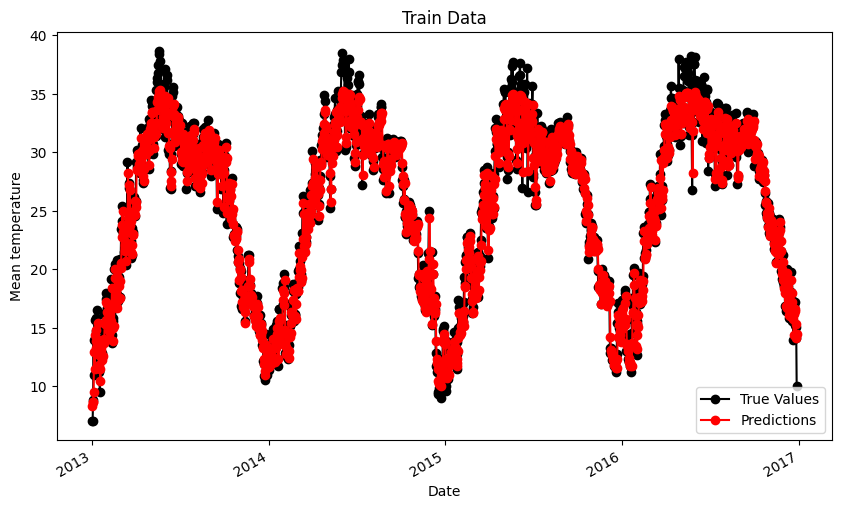

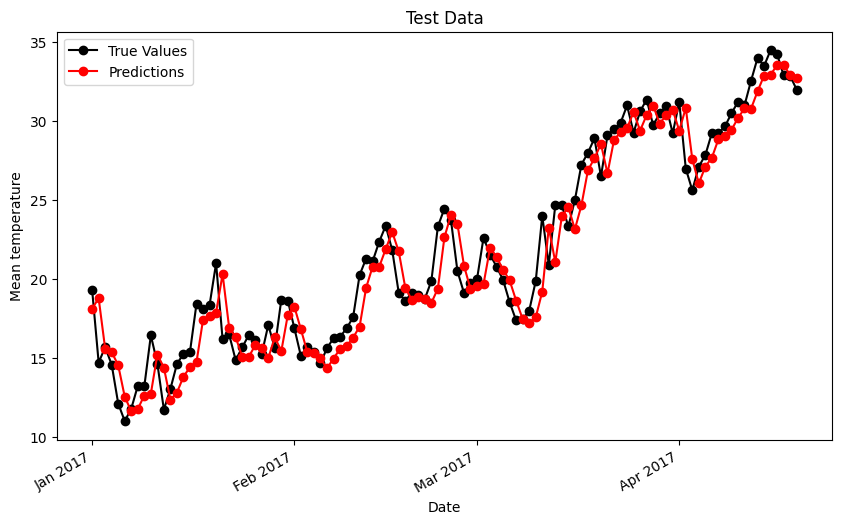

In [19]:
train_period = train[0:len(train) - WINDOW_SIZE]['date']
test_period = test[0:len(test) - WINDOW_SIZE]['date']

plot_predictions(train_pred, train_output, 'Train Data', train_period)
plot_predictions(test_pred, test_output, 'Test Data', test_period)

It seems that the model is trained well, it follows the direction of the trend very well.

But there is a question remaining, can we predict the future?

In [20]:
predictions = []

def predict_the_future(input_seq, period_prediction: int = 7):
    if period_prediction == 0:
        return None
    new_prediction = model.predict(input_seq)
    predictions.append(new_prediction[0][0])

    # input_seq = [[0], [1], [2], [3], [4]]
    # prediction = [5]
    # --> new_seq = [[1], [2], [3], [4], [5]]
    new_seq = np.array([np.concatenate((input_seq[0][1:WINDOW_SIZE], new_prediction[0]))])

    predict_the_future(new_seq, period_prediction - 1)

In [21]:
seq_start = np.array([[15, 15.5, 16, 17, 18]])

if len(seq_start[0]) != WINDOW_SIZE:
    raise "Size mismatch"
predict_the_future(seq_start)

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


[np.float32(17.32596),
 np.float32(17.005096),
 np.float32(16.710072),
 np.float32(16.440376),
 np.float32(16.109604),
 np.float32(15.77255),
 np.float32(15.422119)]